# Actividad 1 - Regresión lineal

**Aprendizaje Automático - Clase 4**

Objetivo: aplicar regresión lineal para predecir una variable continua utilizando un dataset de diabetes.

Dataset: Diabetes de Scikit-learn, con 442 pacientes, 10 variables predictoras y una variable objetivo que representa la progresión de la enfermedad.

## 1. Preparación y organización de los datos

Se carga el dataset de diabetes y se organiza en un DataFrame de Pandas. Posteriormente, se guarda en formato CSV y se comprueban sus dimensiones y la existencia de valores faltantes.

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Cargar el dataset de diabetes
diabetes = load_diabetes(as_frame=True)

# Convertir los datos en un DataFrame
df = diabetes.frame

# Mostrar los primeros cinco pacientes
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
# Guardar el dataset en formato CSV
df.to_csv("../Dataset/diabetes_regresion.csv", index=False)

print("Dataset guardado correctamente")

Dataset guardado correctamente


In [3]:
# Comprobar la cantidad de pacientes y variables
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (442, 11)


In [4]:
# Comprobar si existen valores faltantes
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

## 2. Exploración de los datos

Se analiza la variable objetivo `target` para conocer sus principales características estadísticas antes de construir el modelo de regresión lineal.

In [5]:
# Explorar la variable objetivo: progresión de la diabetes
df["target"].describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

### Distribución de la variable objetivo

Se utiliza un histograma para visualizar la distribución de los valores de progresión de la diabetes en los 442 pacientes.

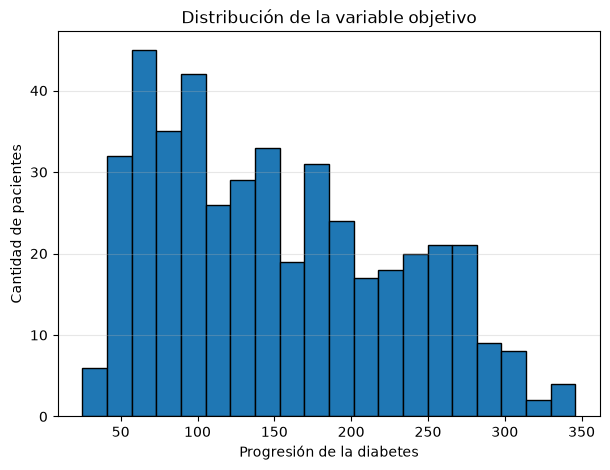

In [14]:
import matplotlib.pyplot as plt

# Histograma de la variable objetivo
plt.figure(figsize=(7, 5))

plt.hist(df["target"], bins=20, edgecolor="black")

plt.xlabel("Progresión de la diabetes")
plt.ylabel("Cantidad de pacientes")
plt.title("Distribución de la variable objetivo")

plt.grid(axis="y", alpha=0.3)
plt.show()

**Interpretación:** La mayor concentración de pacientes presenta valores de progresión de la diabetes entre 50 y 150. Se observa una menor frecuencia de pacientes con valores superiores a 300.

### Relación entre el índice de masa corporal y la progresión de la diabetes

Se utiliza un gráfico de dispersión para explorar la relación entre el índice de masa corporal (bmi) y la variable objetivo (target).

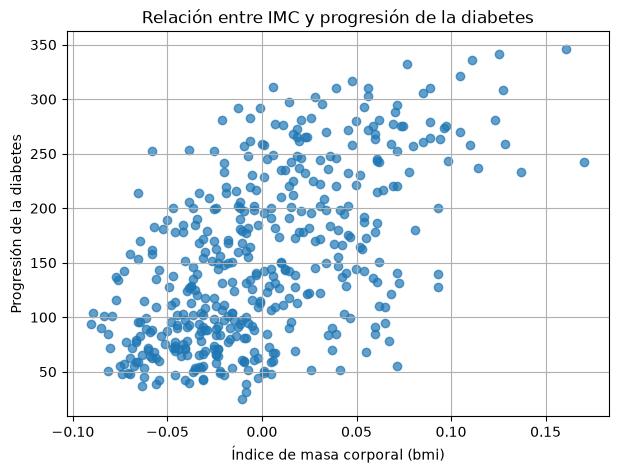

In [15]:
# Explorar la relación entre el IMC y la progresión de la diabetes

plt.figure(figsize=(7, 5))

plt.scatter(df["bmi"], df["target"], alpha=0.7)

plt.xlabel("Índice de masa corporal (bmi)")
plt.ylabel("Progresión de la diabetes")
plt.title("Relación entre IMC y progresión de la diabetes")

plt.grid(True)
plt.show()

**Interpretación:** Se observa una tendencia positiva entre el IMC y la progresión de la diabetes. Sin embargo, existe dispersión entre los valores, por lo que el IMC por sí solo no permite explicar completamente la progresión de la enfermedad.

## 3. Modelado de datos

Se aplica regresión lineal para predecir la progresión de la diabetes a partir de las diez variables predictoras del dataset.

In [6]:
# Separar las variables predictoras y la variable objetivo
X = df.drop(columns=["target"])
y = df["target"]

# Comprobar las dimensiones
print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (442, 10)
Variable objetivo: (442,)


### División de los datos en entrenamiento y prueba

Se divide el dataset en dos grupos: 80 % para entrenar el modelo de regresión lineal y 20 % para evaluar su capacidad de predecir valores en pacientes que no fueron utilizados durante el entrenamiento.

In [7]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Comprobar la cantidad de pacientes en cada grupo
print("Pacientes para entrenamiento:", X_train.shape[0])
print("Pacientes para prueba:", X_test.shape[0])

Pacientes para entrenamiento: 353
Pacientes para prueba: 89


### Entrenamiento del modelo

Se entrena un modelo de regresión lineal utilizando las diez variables predictoras y los datos de los 353 pacientes destinados al entrenamiento.

In [8]:
from sklearn.linear_model import LinearRegression

# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


### Predicción de la variable objetivo

Se utiliza el modelo entrenado para predecir la progresión de la diabetes en los 89 pacientes del conjunto de prueba.

In [9]:
# Realizar predicciones con los datos de prueba
y_pred = modelo.predict(X_test)

# Comparar los primeros cinco valores reales y predichos
import pandas as pd

resultados = pd.DataFrame({
    "Valor real": y_test.values,
    "Valor predicho": y_pred
})

resultados.head()

,Valor real,Valor predicho
0,219.0,139.547558
1,70.0,179.517208
2,202.0,134.038756
3,230.0,291.417029
4,111.0,123.789659


### Evaluación del modelo

Se evalúa el rendimiento de la regresión lineal comparando los valores reales con los valores predichos mediante el error absoluto medio (MAE), el error cuadrático medio (MSE) y el coeficiente de determinación (R²).

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluar el modelo con los datos de prueba
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Error absoluto medio (MAE):", mae)
print("Error cuadrático medio (MSE):", mse)
print("Coeficiente de determinación (R²):", r2)

Error absoluto medio (MAE): 42.794094679599944
Error cuadrático medio (MSE): 2900.193628493482
Coeficiente de determinación (R²): 0.45260276297191937


### Visualización de los resultados

Se representan gráficamente los valores reales y los valores predichos por el modelo de regresión lineal para observar las diferencias entre ambos.

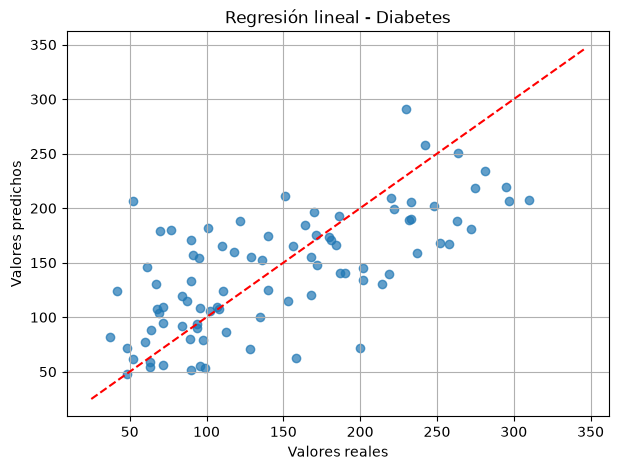

In [11]:
import matplotlib.pyplot as plt

# Graficar los valores reales y predichos
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.7)

# Dibujar la línea de predicción perfecta
plt.plot([25, 346], [25, 346], "r--")

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión lineal - Diabetes")

plt.grid(True)
plt.show()

## 4. Conclusión

Se aplicó un modelo de regresión lineal para predecir la progresión de la diabetes utilizando diez variables predictoras de un dataset de 442 pacientes.

El modelo se entrenó con 353 pacientes y se evaluó con los 89 restantes.

Los resultados obtenidos fueron:

- Error absoluto medio (MAE): 42,79.
- Error cuadrático medio (MSE): 2900,19.
- Coeficiente de determinación (R²): 0,4526.

El modelo logró explicar aproximadamente el 45,26 % de la variabilidad de la variable objetivo en los datos de prueba.

Se concluye que la regresión lineal permite realizar predicciones sobre la progresión de la diabetes, aunque los errores observados indican que su capacidad predictiva es limitada.